In [1]:
import pandas as pd
import os
import pickle
import numpy as np
import mygene

In [2]:
mg = mygene.MyGeneInfo()

def uniprot_to_gene_symbol(uniprot_ids, species="human"):
    """
    Convert UniProt IDs to gene symbols.

    Parameters
    ----------
    uniprot_ids : list[str]
        UniProt accession IDs (e.g. ["P04637", "Q9Y263"])
    species : str or int
        Species name or taxonomy ID (default: "human")

    Returns
    -------
    dict
        {uniprot_id: gene_symbol or None}
    """
    results = mg.querymany(
        uniprot_ids,
        scopes="uniprot",
        fields="symbol",
        species=species
    )

    mapping = {}
    for r in results:
        uid = r["query"]
        mapping[uid] = None if r.get("notfound") else r.get("symbol")

    return mapping


In [31]:
disease = 'ICD10_I70'
root = '/itf-fi-ml/shared/users/ziyuzh/svm/results/df_gnn_occsvm_pred'

with open(os.path.join(root,disease+'_pred.pkl'), "rb") as f:
    data = pickle.load(f)
test_indices = data['test_genes']
final_y_score = data['mid_geo_fused_ppi']
# Example
uniprot_ids = test_indices[np.argsort(final_y_score)[::-1]][:50].tolist()
mapping = uniprot_to_gene_symbol(uniprot_ids)

for k, v in mapping.items():
    print(f"{k}: {v}")

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


P01584: IL1B
P14780: MMP9
P00747: PLG
P09601: HMOX1
P04054: PLA2G1B
P34810: CD68
P22301: IL10
P05019: IGF1
Q8WTV0: SCARB1
P05305: EDN1
P13726: F3
P05164: MPO
P08253: MMP2
P01033: TIMP1
P20813: CYP2B6
P01583: IL1A
P41159: LEP
P02647: APOA1
P12821: ACE
P10145: CXCL8
Q14116: IL18
P01137: TGFB1
P08519: LPA
P16671: CD36
P08254: MMP3
P05181: CYP2E1
P45983: MAPK8
P14210: HGF
P04150: NR3C1
P05112: IL4
P07204: THBD
P00450: CP
P20333: TNFRSF1B
P04040: CAT
P11215: ITGAM
Q14108: SCARB2
P00734: F2
O60760: HPGDS
P04114: APOB
P25445: FAS
P08758: ANXA5
P11597: CETP
P10451: SPP1
P04275: VWF
Q07812: BAX
P29279: CCN2
P04839: CYBB
O14756: HSD17B6
P16109: SELP
Q9HD89: RETN


In [6]:
data['true_label'].sum()

3

In [4]:
import gseapy as gp

## only KEGG

In [20]:
gp.get_library_name()

['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'CM4AI_U2OS_Protein_Localization_Assemblies',
 'COMPARTMENTS_Curated_2025',
 'COMPARTMENTS_Experimental_2025',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'Carcinogenome',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'ClinVar_2025',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popul

In [10]:
gene_names = list(mapping.values())
enrich_db = [
    'KEGG_2021_Human']

enr = gp.enrichr(
    gene_list=gene_names,
    gene_sets=enrich_db,
    organism='human',
    outdir=None
)
enr_df = enr.results
sig = enr_df[enr_df["Adjusted P-value"] < 0.01].copy()

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp

from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, leaves_list

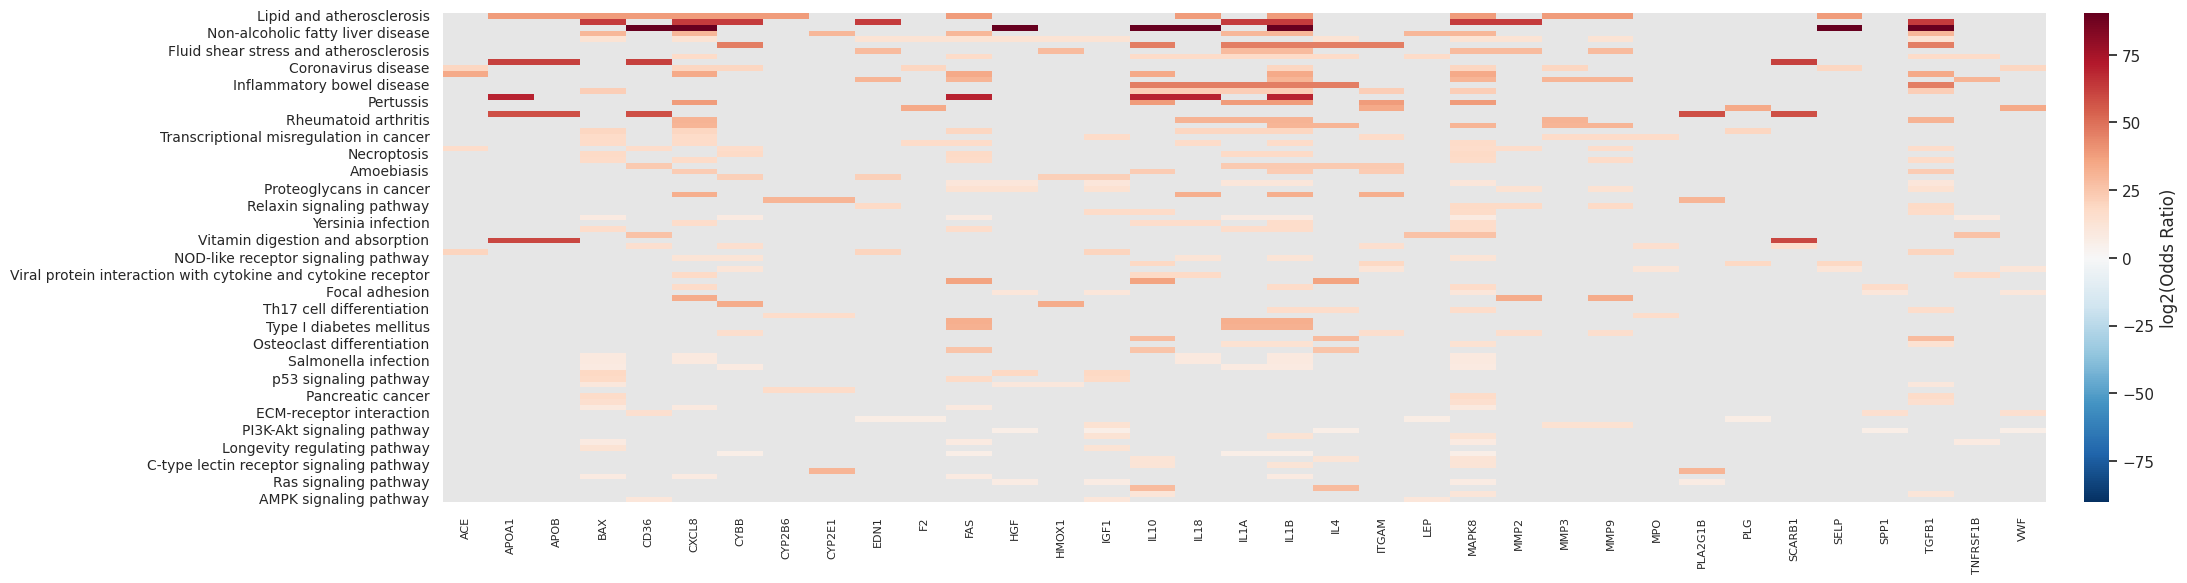

In [17]:
if sig.empty:
    raise ValueError("No significant pathways found at Adjusted P-value < 0.01.")

# -----------------------
# 2) Build pathway × gene matrix with Odds Ratio for overlapping genes
# -----------------------
required_cols = ["Term", "Genes", "Odds Ratio"]
missing = [c for c in required_cols if c not in sig.columns]
if missing:
    raise KeyError(f"Missing expected columns: {missing}. Available: {list(sig.columns)}")

sig_sub = sig[required_cols].copy()
sig_sub["Genes"] = sig_sub["Genes"].astype(str).str.split(";")

all_genes = sorted({g for genes in sig_sub["Genes"] for g in genes if g})

heatmap_or = pd.DataFrame(np.nan, index=sig_sub["Term"], columns=all_genes)
for _, row in sig_sub.iterrows():
    term = row["Term"]
    or_val = float(row["Odds Ratio"])
    for g in row["Genes"]:
        if g in heatmap_or.columns:
            heatmap_or.loc[term, g] = or_val

# Optional: drop genes that appear in only 1 pathway (often cleans things up)
min_pathways_per_gene = 4
keep = heatmap_or.notna().sum(axis=0) >= min_pathways_per_gene
heatmap_or = heatmap_or.loc[:, keep]

# -----------------------
# 3) log2 transform (NaNs stay NaN)
# -----------------------
heatmap_log2or = heatmap_or

# -----------------------
sns.set_theme(style="white")  # clean background

# Make NaNs appear as light gray (like the screenshot background)
nan_bg = "#e6e6e6"

# Diverging colormap blue-white-red
cmap = plt.cm.RdBu_r.copy()     # blue low, red high
cmap.set_bad(color=nan_bg)      # NaNs -> gray

# Symmetric range around 0 is usually best for log2(OR)
# If you prefer using actual min/max, replace with vmin/vmax = np.nanmin/np.nanmax
abs_max = np.nanmax(np.abs(heatmap_log2or.to_numpy()))
vmin, vmax = -abs_max, abs_max

# -----------------------
# Plot
# -----------------------
fig, ax = plt.subplots(figsize=(24, 6))  # wide like your example
ax.set_facecolor(nan_bg)

hm = sns.heatmap(
    heatmap_log2or,
    ax=ax,
    cmap=cmap,
    vmin=vmin, vmax=vmax,
    center=0,                         # log2(1) = 0 (white)
    mask=heatmap_log2or.isna(),       # keep NaNs as background
    linewidths=0,                     # no grid lines
    linecolor=None,
    cbar=True,
    cbar_kws={
        "label": "log2(Odds Ratio)",
        "shrink": 1.0,
        "pad": 0.02
    }
)

# Axis labels + title (keep minimal like screenshot)
ax.set_xlabel("")
ax.set_ylabel("")

# Tick styling: x vertical, small font; y readable
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", va="top", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

# Remove spines (clean look)
for spine in ax.spines.values():
    spine.set_visible(False)

# Tight layout to fit long gene names
plt.tight_layout()
plt.show()


/itf-fi-ml/shared/users/ziyuzh/.venv/lib64/python3.11/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/itf-fi-ml/shared/users/ziyuzh/.venv/lib64/python3.11/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we ar

<Figure size 1000x500 with 0 Axes>

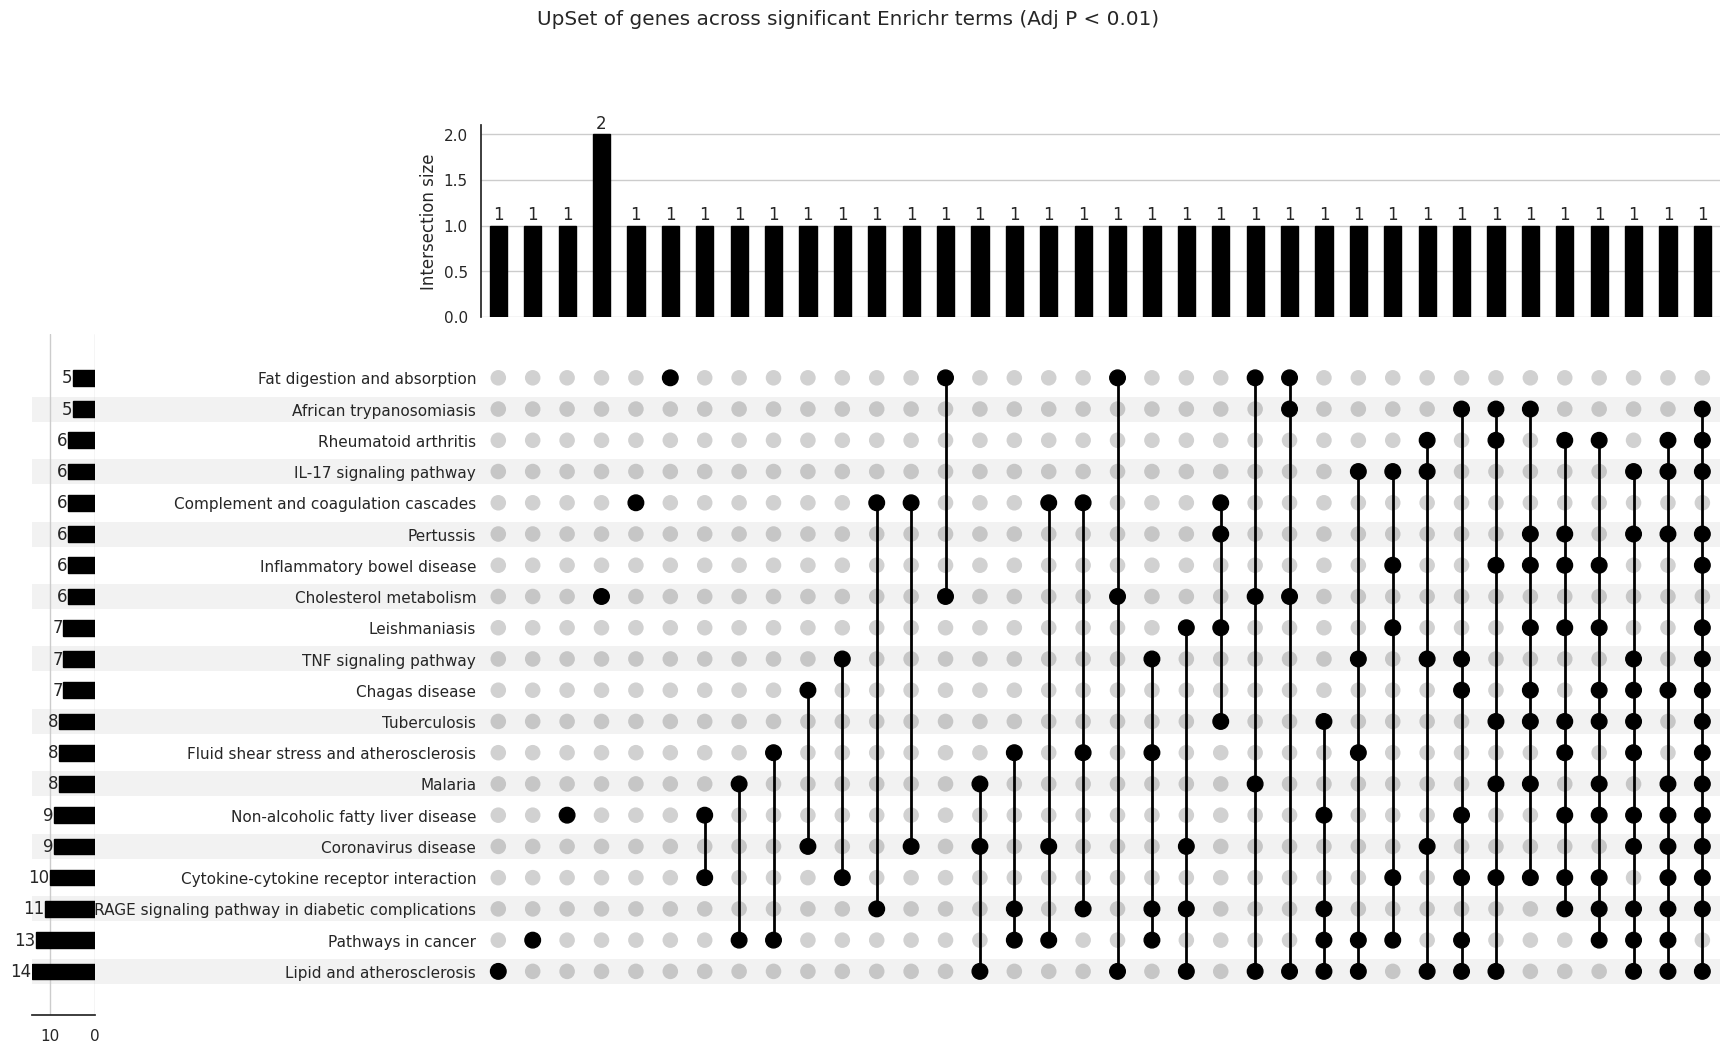

In [18]:
# pip install upsetplot
from upsetplot import UpSet, from_indicators

# --- sig is your filtered Enrichr results ---
# sig = enr_df[enr_df["Adjusted P-value"] < 0.01].copy()

# Enrichr typically stores genes as a ';' separated string in the "Genes" column
# and term name in "Term". (Sometimes "Gene_set" is also present.)
# We'll build: rows=genes, cols=terms, values=True/False

# 1) Pick a manageable number of terms (optional but recommended)
sig2 = sig.sort_values("Adjusted P-value").head(20).copy()

# 2) Parse each term's gene list
term2genes = {
    row["Term"]: [g.strip() for g in str(row["Genes"]).split(";") if g.strip()]
    for _, row in sig2.iterrows()
}

# 3) Build indicator (membership) matrix: genes x terms
all_genes = sorted({g for genes in term2genes.values() for g in genes})
indicator = pd.DataFrame(False, index=all_genes, columns=list(term2genes.keys()))

for term, genes in term2genes.items():
    indicator.loc[genes, term] = True

# 4) Convert to upsetplot input and plot
data = from_indicators(indicator.columns, indicator)

plt.figure(figsize=(10, 5))
UpSet(data, show_counts=True, show_percentages=False, min_subset_size=1).plot()
plt.suptitle("UpSet of genes across significant Enrichr terms (Adj P < 0.01)")
plt.tight_layout()
plt.show()


## GO and KEGG

In [61]:
uniprot_ids = test_indices[np.argsort(final_y_score)[::-1]][:200].tolist()
mapping = uniprot_to_gene_symbol(uniprot_ids)

gene_names = list(mapping.values())
enrich_db = [
    'GO_Biological_Process_2025',
    'GO_Cellular_Component_2025',
    'GO_Molecular_Function_2025',
    'KEGG_2026'
]

enr = gp.enrichr(
    gene_list=gene_names,
    gene_sets=enrich_db,
    organism='human',
    outdir=None
)
enr_df = enr.results
sig = enr_df[enr_df["Adjusted P-value"] < 0.01].copy()

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


### KEGG 2026, GO 2025, top 100

<Axes: title={'center': 'KEGG – Top 10 pathways'}, xlabel='Combined Score'>

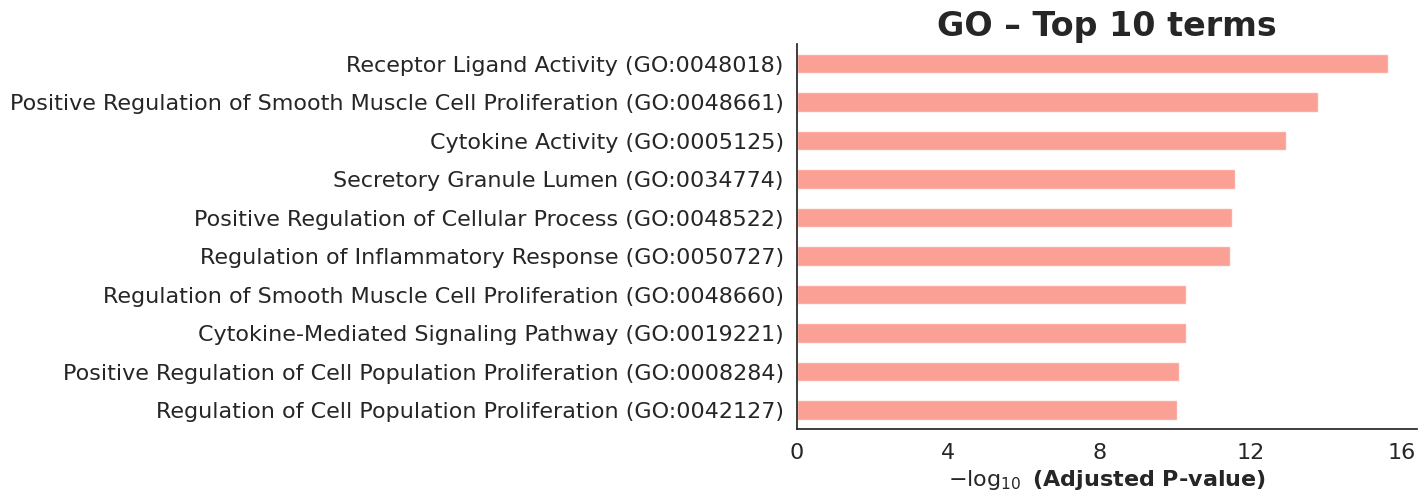

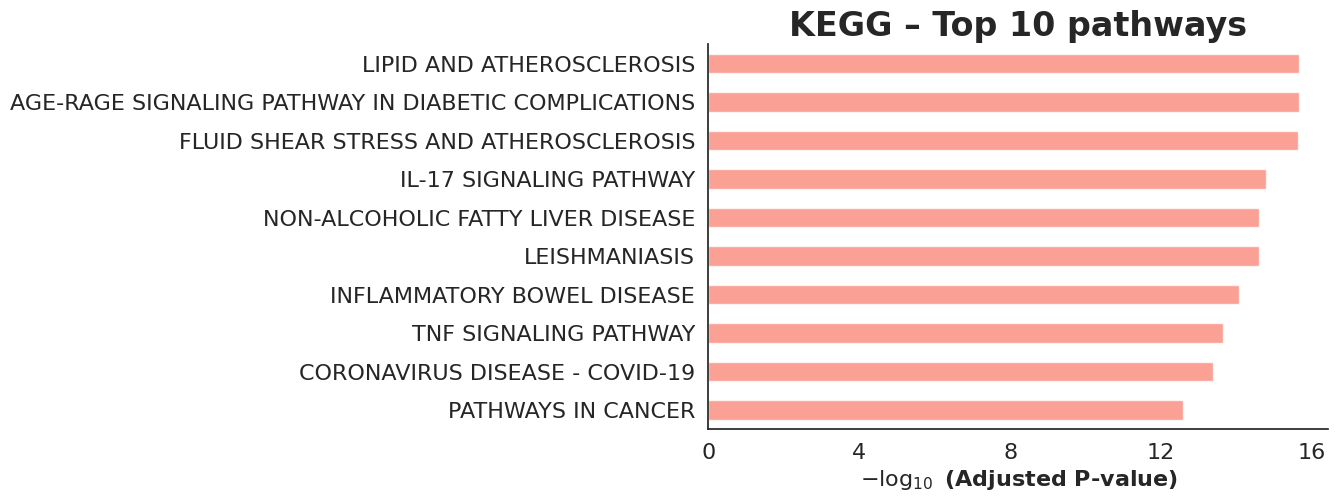

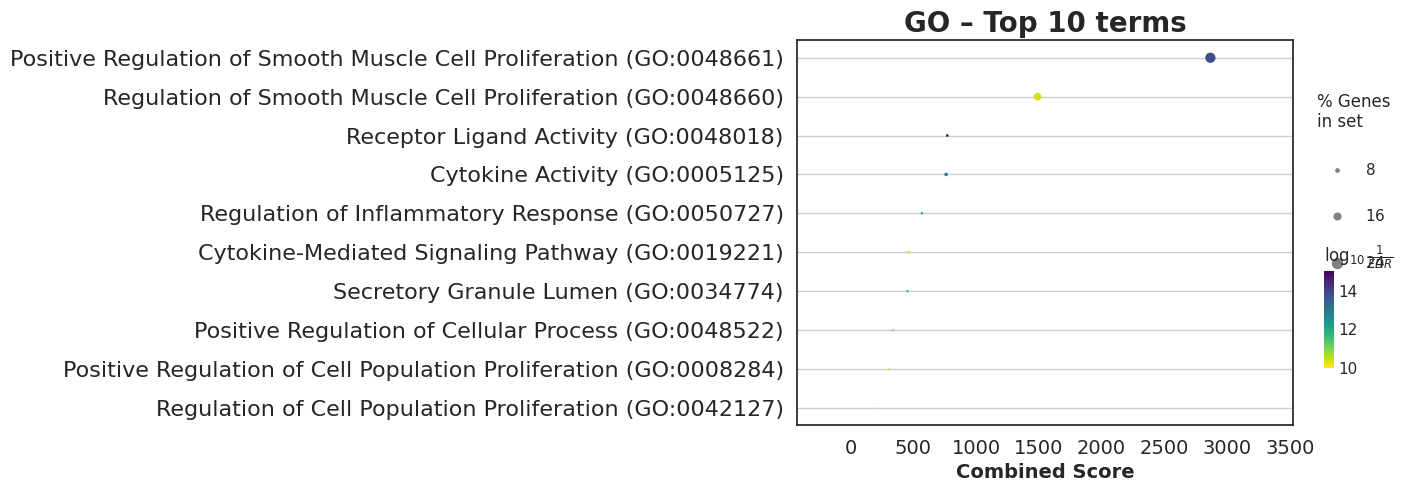

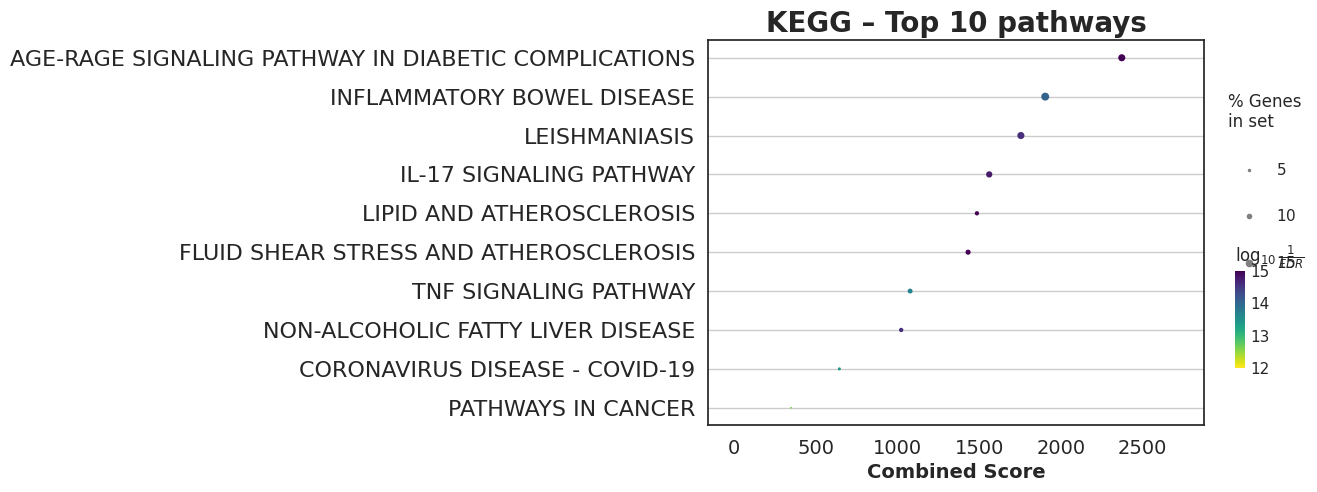

In [60]:

# ---- Split: GO (combined) vs KEGG ----
go_df = sig[sig["Gene_set"].str.startswith("GO_")].copy()
kegg_df = sig[sig["Gene_set"] == "KEGG_2026"].copy()

# Top 10 (GO combined across all GO libraries; KEGG separately)
top_n = 10
go_top10 = go_df.sort_values("Adjusted P-value").head(top_n)
kegg_top10 = kegg_df.sort_values("Adjusted P-value").head(top_n)

# ---- Plot separately using gseapy built-ins ----
# GO
gp.barplot(
    go_top10,
    column="Adjusted P-value",
    top_term=top_n,
    figsize=(8, 5),
    title="GO – Top 10 terms",
)

# KEGG
gp.barplot(
    kegg_top10,
    column="Adjusted P-value",
    top_term=top_n,
    figsize=(8, 5),
    title="KEGG – Top 10 pathways",
)

# If you also want dotplots (optional):
gp.dotplot(go_top10, column="Adjusted P-value", top_term=top_n, figsize=(8, 5), title="GO – Top 10 terms")
gp.dotplot(kegg_top10, column="Adjusted P-value", top_term=top_n, figsize=(8, 5), title="KEGG – Top 10 pathways")


### KEGG 2026, GO 2025, top 50

<Axes: title={'center': 'KEGG – Top 10 pathways'}, xlabel='Combined Score'>

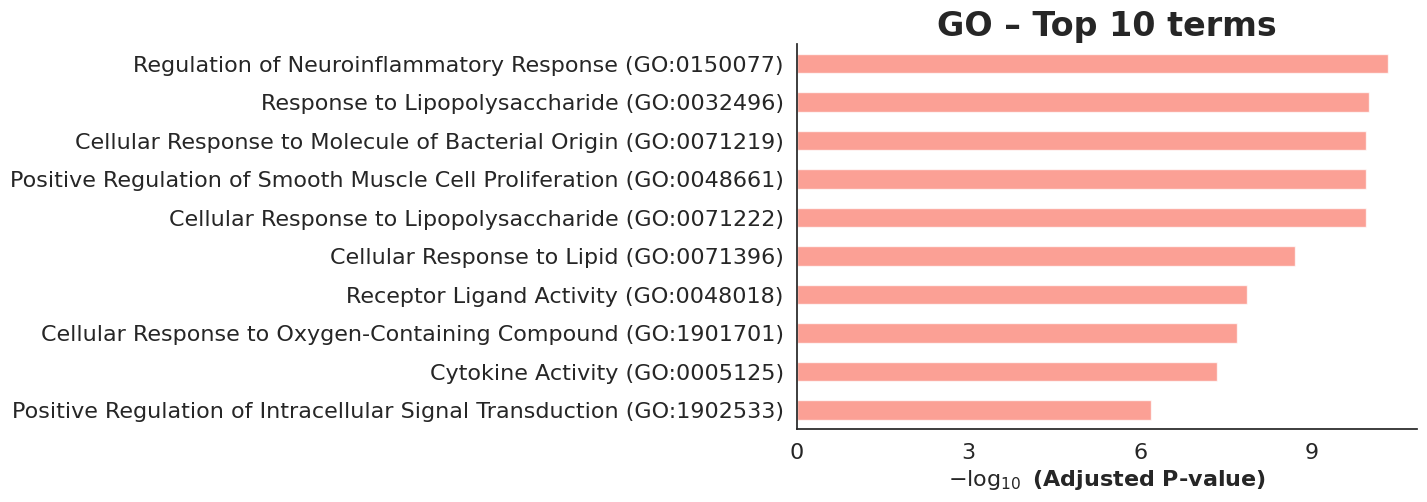

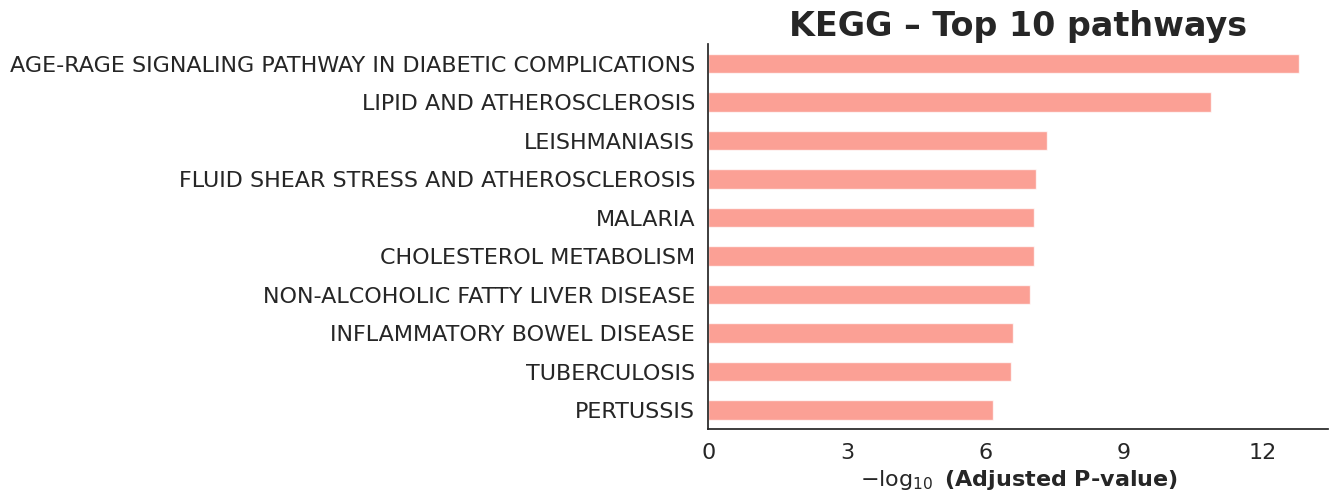

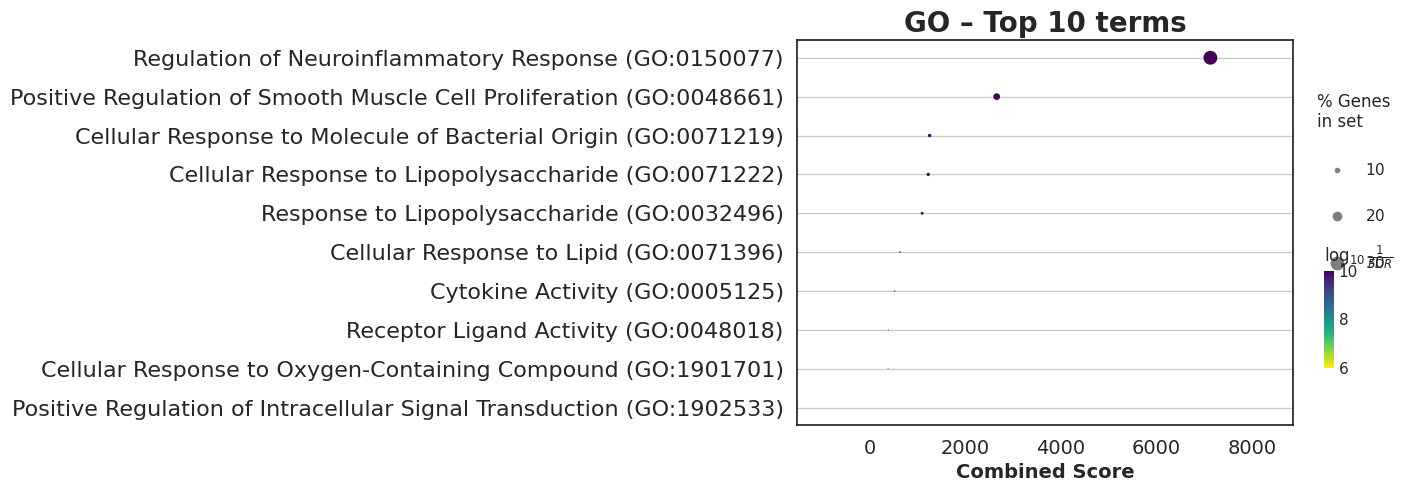

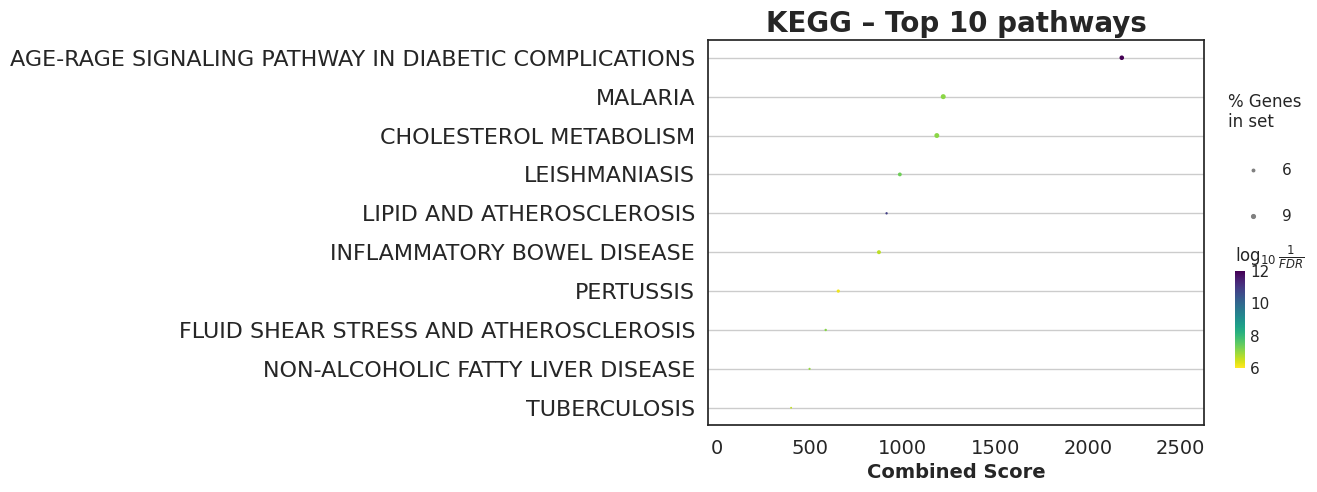

In [23]:

# ---- Split: GO (combined) vs KEGG ----
go_df = sig[sig["Gene_set"].str.startswith("GO_")].copy()
kegg_df = sig[sig["Gene_set"] == "KEGG_2026"].copy()

# Top 10 (GO combined across all GO libraries; KEGG separately)
top_n = 10
go_top10 = go_df.sort_values("Adjusted P-value").head(top_n)
kegg_top10 = kegg_df.sort_values("Adjusted P-value").head(top_n)

# ---- Plot separately using gseapy built-ins ----
# GO
gp.barplot(
    go_top10,
    column="Adjusted P-value",
    top_term=top_n,
    figsize=(8, 5),
    title="GO – Top 10 terms",
)

# KEGG
gp.barplot(
    kegg_top10,
    column="Adjusted P-value",
    top_term=top_n,
    figsize=(8, 5),
    title="KEGG – Top 10 pathways",
)

# If you also want dotplots (optional):
gp.dotplot(go_top10, column="Adjusted P-value", top_term=top_n, figsize=(8, 5), title="GO – Top 10 terms")
gp.dotplot(kegg_top10, column="Adjusted P-value", top_term=top_n, figsize=(8, 5), title="KEGG – Top 10 pathways")


### KEGG 2016, GO 2021, top 100

<Axes: title={'center': 'KEGG – Top 10 pathways'}, xlabel='Combined Score'>

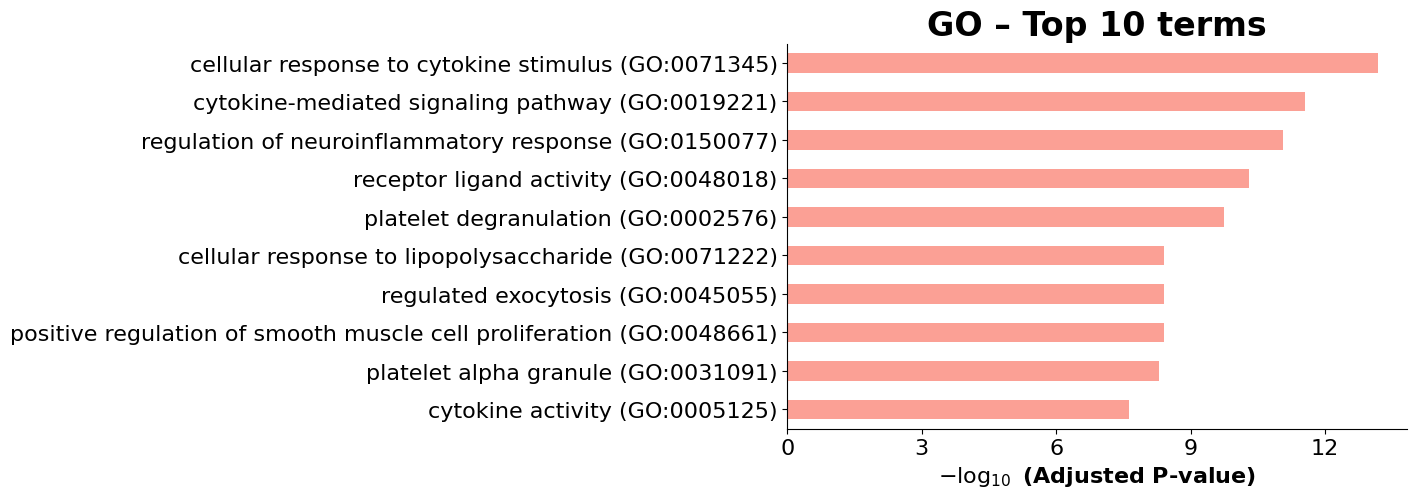

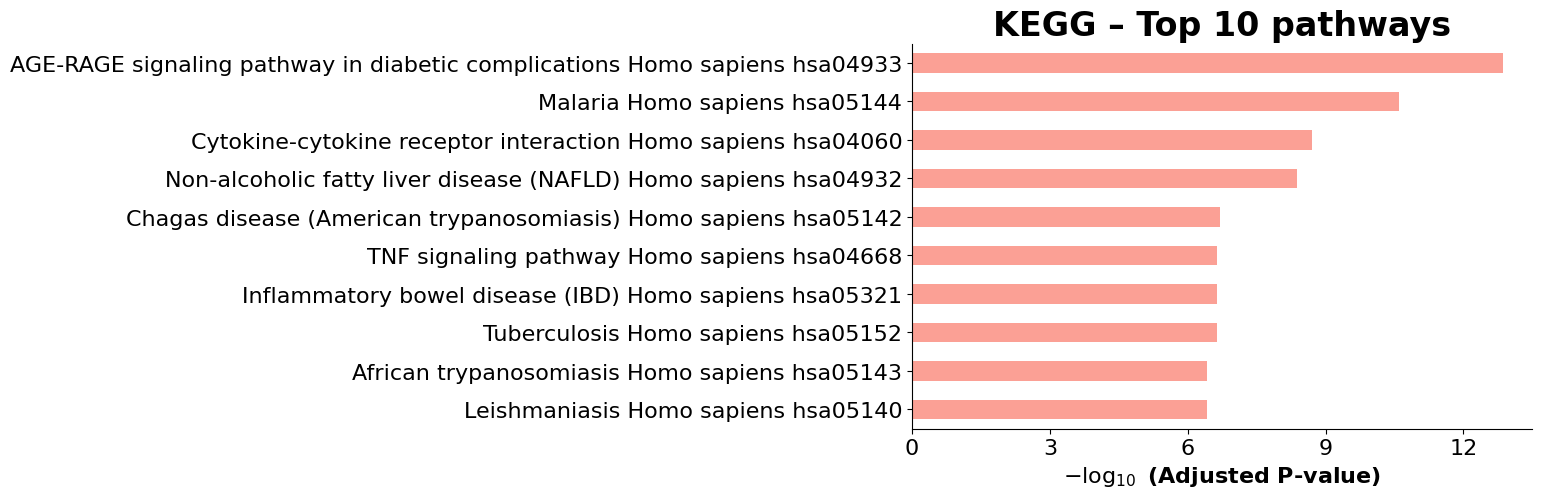

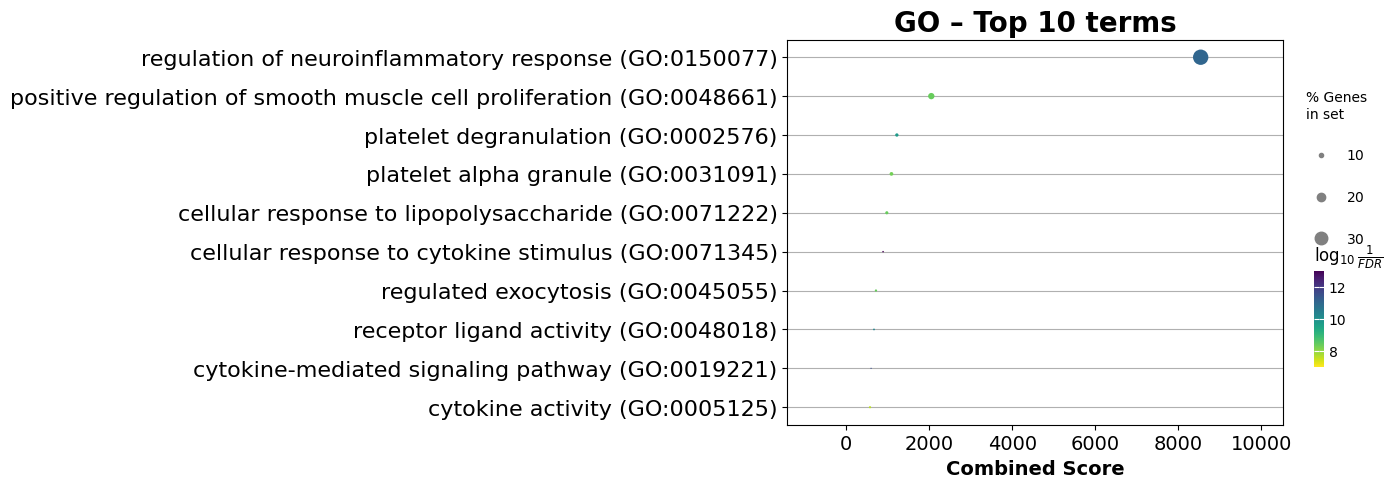

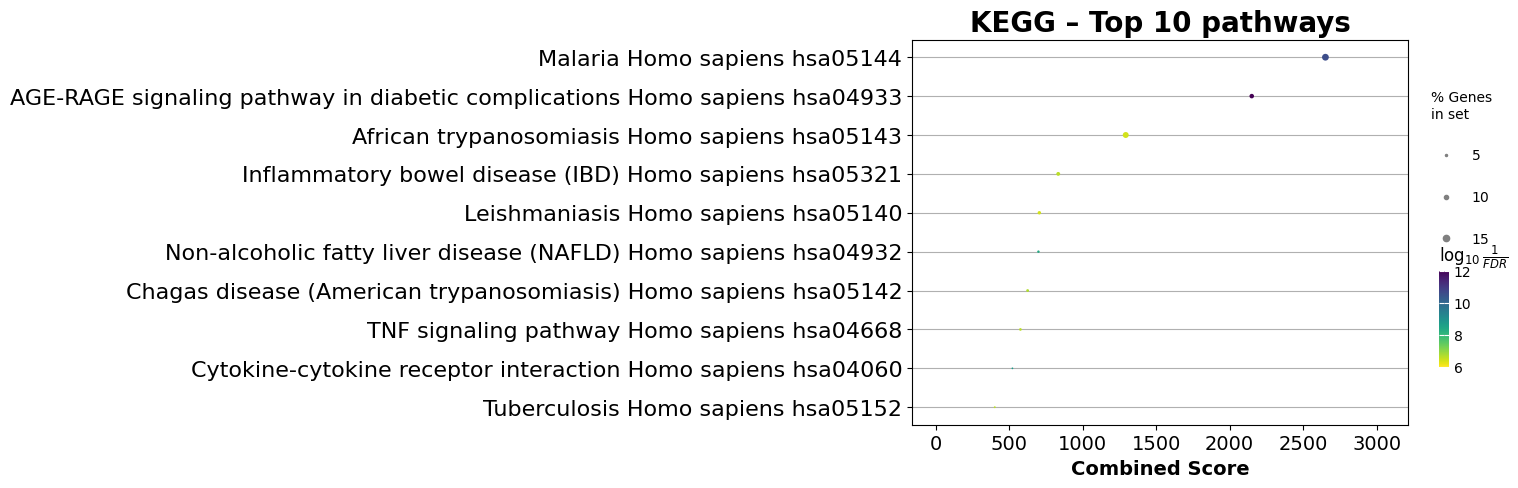

In [ ]:

# ---- Split: GO (combined) vs KEGG ----
go_df = sig[sig["Gene_set"].str.startswith("GO_")].copy()
kegg_df = sig[sig["Gene_set"] == "KEGG_2016"].copy()

# Top 10 (GO combined across all GO libraries; KEGG separately)
top_n = 10
go_top10 = go_df.sort_values("Adjusted P-value").head(top_n)
kegg_top10 = kegg_df.sort_values("Adjusted P-value").head(top_n)

# ---- Plot separately using gseapy built-ins ----
# GO
gp.barplot(
    go_top10,
    column="Adjusted P-value",
    top_term=top_n,
    figsize=(8, 5),
    title="GO – Top 10 terms",
)

# KEGG
gp.barplot(
    kegg_top10,
    column="Adjusted P-value",
    top_term=top_n,
    figsize=(8, 5),
    title="KEGG – Top 10 pathways",
)

# If you also want dotplots (optional):
gp.dotplot(go_top10, column="Adjusted P-value", top_term=top_n, figsize=(8, 5), title="GO – Top 10 terms")
gp.dotplot(kegg_top10, column="Adjusted P-value", top_term=top_n, figsize=(8, 5), title="KEGG – Top 10 pathways")


## t-SNE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [ ]:
# with open(os.path.join(root,disease+'_pred.pkl'), "rb") as f:
#     data = pickle.load(f)
# test_indices = data['test_genes']
# final_y_score = data['mid_geo_fused_ppi']
# # Example
# uniprot_ids = test_indices[np.argsort(final_y_score)[::-1]][:50].tolist()

from features_reindex import get_feature
feature_df = get_feature('/itf-fi-ml/shared/users/ziyuzh/svm', 'uniport_ppi_2019')
train_pos_genes = data['train_pos_genes']
all_avl_genes = set(train_pos_genes) | set(test_indices)
feature_df = feature_df[feature_df['string_id'].isin(list(all_avl_genes))]


In [55]:
# first column contains IDs
id_col = feature_df.columns[0]

# X: all columns except the first
X = feature_df.iloc[:, 1:].copy()

# 1. Standardize
X = StandardScaler().fit_transform(X)

# 2. PCA (denoise + speed up)
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X)

print(f"Explained variance (50 PCs): {pca.explained_variance_ratio_.sum():.2%}")

# 3. t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=50,
    learning_rate="auto",
    init="pca",
    n_iter=1500,
    random_state=42,
    verbose=1,
)
X_tsne = tsne.fit_transform(X_pca)


Explained variance (50 PCs): 55.44%
[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 15686 samples in 0.003s...


/itf-fi-ml/shared/users/ziyuzh/.venv/lib64/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 15686 samples in 1.226s...
[t-SNE] Computed conditional probabilities for sample 1000 / 15686
[t-SNE] Computed conditional probabilities for sample 2000 / 15686
[t-SNE] Computed conditional probabilities for sample 3000 / 15686
[t-SNE] Computed conditional probabilities for sample 4000 / 15686
[t-SNE] Computed conditional probabilities for sample 5000 / 15686
[t-SNE] Computed conditional probabilities for sample 6000 / 15686
[t-SNE] Computed conditional probabilities for sample 7000 / 15686
[t-SNE] Computed conditional probabilities for sample 8000 / 15686
[t-SNE] Computed conditional probabilities for sample 9000 / 15686
[t-SNE] Computed conditional probabilities for sample 10000 / 15686
[t-SNE] Computed conditional probabilities for sample 11000 / 15686
[t-SNE] Computed conditional probabilities for sample 12000 / 15686
[t-SNE] Computed conditional probabilities for sample 13000 / 15686
[t-SNE] Computed conditional probabilities for sample 14000 / 15686

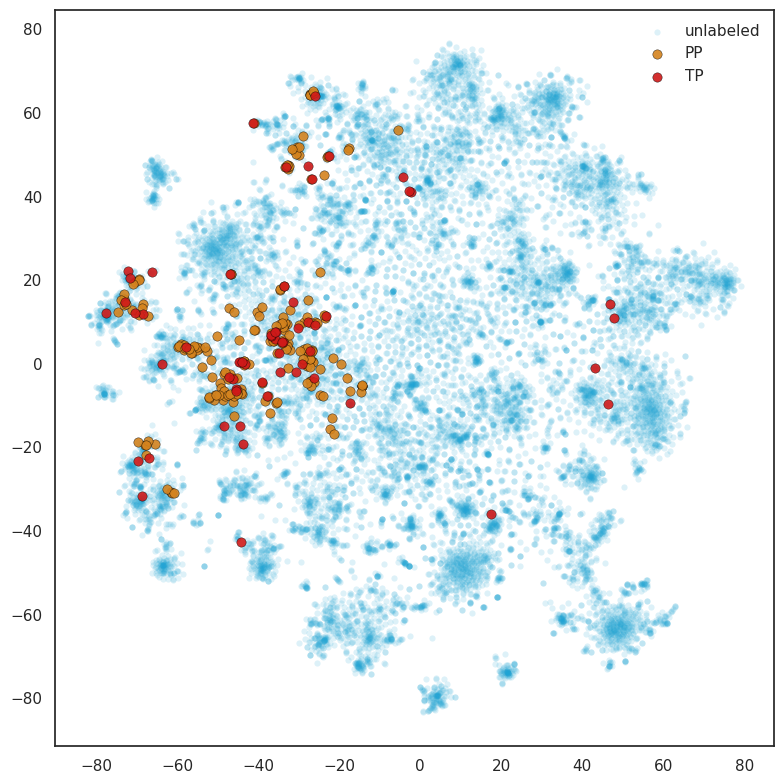

In [57]:
uniprot_ids = test_indices[np.argsort(final_y_score)[::-1]][:200].tolist()
others = set(test_indices)-set(uniprot_ids)

Y = pd.Series(0, index=feature_df.index, name="label")

# assign labels
Y[feature_df[id_col].isin(uniprot_ids)] = 1
Y[feature_df[id_col].isin(train_pos_genes)] = 2

plt.figure(figsize=(8, 8))

# --- masks ---
m_unlab = (Y == 0)
m_pp    = (Y == 1)
m_tp    = (Y == 2)

# --- background first: unlabeled ---
plt.scatter(
    X_tsne[m_unlab, 0], X_tsne[m_unlab, 1],
    c="#1EA4D4",
    s=20,
    alpha=0.15,
    label="unlabeled",
    linewidths=0,
    zorder=1
)

# --- PP ---
plt.scatter(
    X_tsne[m_pp, 0], X_tsne[m_pp, 1],
    c="#D4831E",
    # c = '#48C33C',
    s=45,
    alpha=0.9,
    label="PP",
    edgecolors="black",
    linewidths=0.3,
    zorder=3
)

# --- TP on top ---
plt.scatter(
    X_tsne[m_tp, 0], X_tsne[m_tp, 1],
    c="#CF1919",
    s=45,
    alpha=0.9,
    label="TP",
    edgecolors="black",
    linewidths=0.3,
    zorder=4
)

# cosmetics
plt.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()


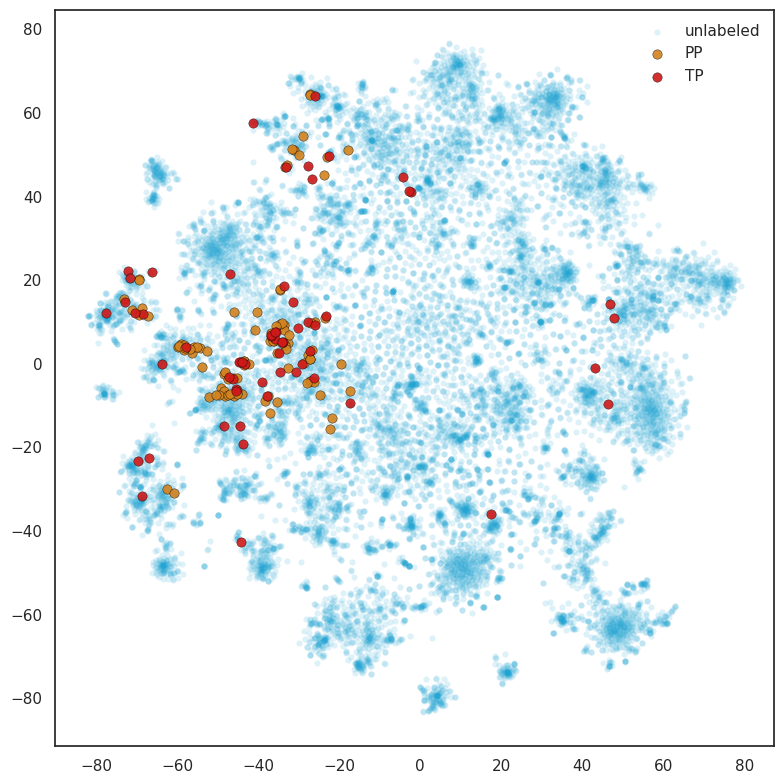

In [56]:
uniprot_ids = test_indices[np.argsort(final_y_score)[::-1]][:100].tolist()
others = set(test_indices)-set(uniprot_ids)

Y = pd.Series(0, index=feature_df.index, name="label")

# assign labels
Y[feature_df[id_col].isin(uniprot_ids)] = 1
Y[feature_df[id_col].isin(train_pos_genes)] = 2

plt.figure(figsize=(8, 8))

# --- masks ---
m_unlab = (Y == 0)
m_pp    = (Y == 1)
m_tp    = (Y == 2)

# --- background first: unlabeled ---
plt.scatter(
    X_tsne[m_unlab, 0], X_tsne[m_unlab, 1],
    c="#1EA4D4",
    s=20,
    alpha=0.15,
    label="unlabeled",
    linewidths=0,
    zorder=1
)

# --- PP ---
plt.scatter(
    X_tsne[m_pp, 0], X_tsne[m_pp, 1],
    c="#D4831E",
    # c = '#48C33C',
    s=45,
    alpha=0.9,
    label="PP",
    edgecolors="black",
    linewidths=0.3,
    zorder=3
)

# --- TP on top ---
plt.scatter(
    X_tsne[m_tp, 0], X_tsne[m_tp, 1],
    c="#CF1919",
    s=45,
    alpha=0.9,
    label="TP",
    edgecolors="black",
    linewidths=0.3,
    zorder=4
)

# cosmetics
plt.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()


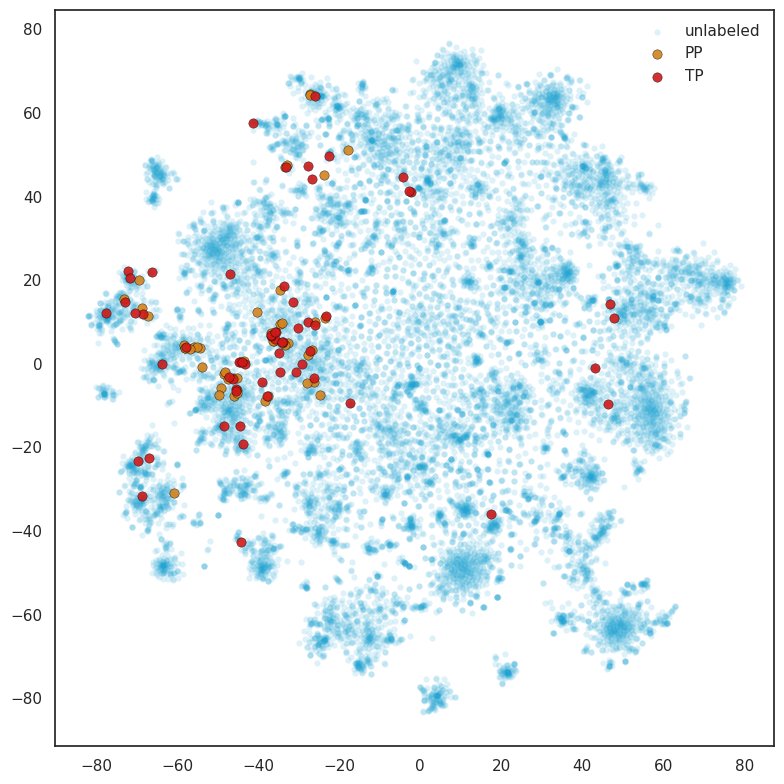

In [ ]:
uniprot_ids = test_indices[np.argsort(final_y_score)[::-1]][:50].tolist()
others = set(test_indices)-set(uniprot_ids)

Y = pd.Series(0, index=feature_df.index, name="label")

# assign labels
Y[feature_df[id_col].isin(uniprot_ids)] = 1
Y[feature_df[id_col].isin(train_pos_genes)] = 2
plt.figure(figsize=(8, 8))

# --- masks ---
m_unlab = (Y == 0)
m_pp    = (Y == 1)
m_tp    = (Y == 2)

# --- background first: unlabeled ---
plt.scatter(
    X_tsne[m_unlab, 0], X_tsne[m_unlab, 1],
    c="#1EA4D4",
    s=20,
    alpha=0.15,
    label="unlabeled",
    linewidths=0,
    zorder=1
)

# --- PP ---
plt.scatter(
    X_tsne[m_pp, 0], X_tsne[m_pp, 1],
    c="#D4831E",
    # c = '#48C33C',
    s=45,
    alpha=0.9,
    label="PP",
    edgecolors="black",
    linewidths=0.3,
    zorder=3
)

# --- TP on top ---
plt.scatter(
    X_tsne[m_tp, 0], X_tsne[m_tp, 1],
    c="#CF1919",
    s=45,
    alpha=0.9,
    label="TP",
    edgecolors="black",
    linewidths=0.3,
    zorder=4
)

# cosmetics
plt.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()


In [44]:
X_tsne

array([[  1.7892425,  -8.963675 ],
       [  7.2528644, -14.901506 ],
       [ 20.170397 ,  -5.258758 ],
       ...,
       [ 21.98517  , -13.852472 ],
       [ 17.366495 ,  22.768387 ],
       [ 60.500744 , -41.941353 ]], dtype=float32)

In [26]:
root_case = '/itf-fi-ml/shared/users/ziyuzh/svm/data/case_study_evidence'
evidences = [
    'human_disease_experiments_full.tsv',
    'human_disease_knowledge_filtered.tsv',
    'human_disease_textmining_filtered.tsv'
]

In [27]:
evidence_i = evidences[2]
ev_df = pd.read_csv(os.path.join(root_case,evidence_i),
    sep="\t",
    header=None,
    names=[
        "Ensembl_Protein_ID",
        "Gene_Symbol",
        "Disease_ID",
        "Disease_Name",
        "Source",
        "MeanRankScore",
        "Score",
    ],
)


In [28]:
len(ev_df[
    (ev_df["Gene_Symbol"].isin(gene_names)) &
    (ev_df["Disease_ID"] == "DOID:1936")
]['Gene_Symbol'].unique())

47

In [29]:
evidence_df

NameError: name 'evidence_df' is not defined

In [ ]:
M34: 'TGFB1','TNF','IL6'
I70: 'SCARB1','IL1B'
C81: 